# Übung 2

**Gruppenname:**

*TKKR*

Gehen Sie wie folgt vor:

1. Bitte benennen Sie jetzt dieses Jupyter Notebook um (z.B. über `File -> Rename`):

   Namensschema: `Gruppenname-X`. Ersetzen Sie "X" mit der oben angegebenen Nummer der Übung.

   - Beispiel 1: Team REZA bearbeitet Übung 2. Das Notebook heißt: REZA-2.
   - Beispiel 2: Sie sind keinem Team zugeordnet (nicht empfehlenswert) und bearbeiten Übung 2: Ihr Notebook heißt: Nachname-2.


2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Vergessen Sie dabei nicht, das Jupyter Notebook regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

In dieser Übung werden wir ...

- 2.1: in einem Experiment das Urnen-Gleichnis aus der Vorlesung untersuchen.
- 2.2: den Perzeptron-Lern-Algorithmus (PLA) implementieren und anwenden.
- 2.3: mithilfe des Perzeptron-Lern-Algorithmus die Schwertlilienarten von letzter Woche klassifizieren. 
- 2.4: (optional) den Perzeptron-Lern-Algorithmus mithilfe eines synthetischen Datensatzes untersuchen.


## 2.1. Multiple Urnen (Hoeffding Ungleichung)

In der Vorlesung haben Sie das Urnenmodell kennengelernt. Insbesondere wurde der Unterschied zwischen einer und mehreren Urnen thematisiert und welche Auswirkung dies auf die Hoeffding-Ungleichung hat. In dieser Übung werden Sie den Unterschied zwischen einer und mehreren Urnen in einem numerischen Experiment untersuchen.

**Experiment**

Betrachten Sie 1000 Münzen. Die Münzen seien fair (also nicht gezinkt). Jede dieser Münzen wird $N=10$ mal geworfen und es wird notiert, ob Kopf oder Zahl gefallen ist. Außerdem wird **für jede einzelne der Münzen** $i$ ($i\in\{1, \ldots, 1000\}$) der Bruchteil $\nu_i$ bestimmt, mit dem bei den 10 Würfen Kopf gefallen ist.

Betrachten Sie nun 3 dieser 1000 Münzen wie folgt:

1. Sie betrachten nur die erste Münze ($i=1$). Der Bruchteil heiße $\nu_1$.
2. Sie betrachten eine zufällig ausgewählte Münze unter den 1000 Münzen. Der Bruchteil heiße $\nu_r$ (*r* für *r*andom).
3. Sie betrachten genau die Münze $m$, für die $\nu$ minimal wird, also $m=\underset{i\in\{1,\ldots, 1000\}}{\operatorname{arg\,min}}(\nu_i)$. Der Bruchteil heiße $\nu_m$ (*m* für minimal).

Bearbeiten Sie die folgenden Teilaufgaben:

(1) Was ist die Wahrscheinlichkeit $\mu$ der Münzen für Kopf? Geben Sie $\mu$ an.

$\mu = 0.5$

(2) Implementieren Sie nun die 10 Zufallswürfe für die 1000 Münzen. Erzeugen Sie dazu eine Variable `coins`, die das Ergebnis der 10 Würfe (Zeilen) für die 1000 Münzen (Spalten) in einer Matrix (numpy array) enthält. Wurde Kopf geworfen, so enthält die Matrix an der entsprechenden Stelle eine $1$. Wurde Zahl geworfen, so enthält sie an der entsprechenden Stelle eine $0$.

- Tipp: Nutzen Sie die [randint](https://numpy.org/doc/stable/reference/random/generated/numpy.random.randint.html) Funktion von Numpy mit dem *size* Parameter, um in einem Befehl alle Münzwürfe zu erzeugen. Überprüfen Sie, dass Ihr Array `coins` tatsächlich nur Nullen und Einsen enthält. 

In [1]:
import numpy as np

In [2]:
muenzen = np.where(np.random.random((10, 1000)) >= 0.5, 1, 0)
muenzen

array([[1, 1, 1, ..., 1, 0, 1],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 1, 0, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 0, 1],
       [0, 0, 1, ..., 1, 1, 0],
       [1, 0, 0, ..., 0, 1, 1]])

(3) Schreiben Sie nun eine Funktion, die den Befehl aus der vorherigen Teilaufgabe nutzt, um 10 Würfe für 1000 Münzen zu erzeugen und darüber hinaus auch $\nu_1$, $\nu_r$ sowie $\nu_m$ bestimmt und als Werte zurückgibt. Beachten Sie, dass $r$ und $m$ dieser neuen Funktion **nicht** übergeben werden, sondern dass $r$ und $m$ unbedingt innerhalb der Funktion bestimmt werden.

Tipps:

- Um eine zufällige Münze auszuwählen, ist [randint](https://numpy.org/doc/stable/reference/random/generated/numpy.random.randint.html) hilfreich.

- Um die Münze $m$ mit dem kleinsten Bruchteil $\nu_m$ auszuwählen, ist [argmin](https://numpy.org/doc/stable/reference/generated/numpy.argmin.html) hilfreich.


In [3]:
def get_vs():
    muenzen = np.where(np.random.random((10, 1000)) >= 0.5, 1, 0)
    vs = muenzen.sum(0) / 10.0
    return vs[0], vs[np.random.randint(0, 1000)], np.min(vs)  
print(get_vs())

(np.float64(0.3), np.float64(0.7), np.float64(0.0))


(4) Nutzen Sie die Funktion aus Teilaufgabe (3), um das Experiment hunderttausendmal zu wiederholen. Erzeugen Sie für $\nu_1$, $\nu_r$ und $\nu_m$ jeweils ein eigenes Numpy Array, welches die 100000 Werte aufnimmt.

In [4]:
N = 100000
v1s = np.zeros(N)
vrs = np.zeros(N)
vms = np.zeros(N)
for i in range(N):
    v1, vr, vm = get_vs()
    v1s[i] = v1
    vrs[i] = vr
    vms[i] = vm

(5) Visualisieren Sie die Verteilung von $\nu_1$ in einem Histogramm. Erzeugen Sie auch entsprechende Visualisierungen für $\nu_r$ und $\nu_m$.

Tipp:

- Nutzen Sie die [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) Funktion von Seaborn, um einfach Histogramme zu erzeugen.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

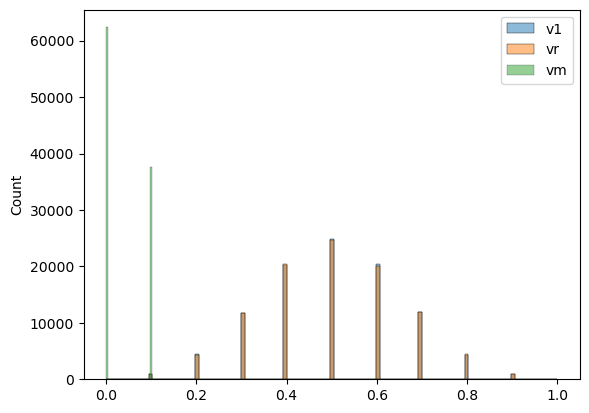

In [6]:
v_dict = {"v1": v1s, "vr": vrs, "vm": vms}

for key in v_dict:
    vs = v_dict[key]
    sns.histplot(vs, label=key, alpha=0.5)
plt.legend()
plt.show()

(6) Betrachten Sie die Visualisierung aus Schritt (5): Welche Münze verhält sich anders als die anderen beiden Münzen? Nennen Sie diese Münze.

$\nu_m$ verhält sich anders, als v1 und vr, da sie immer die geringste Anzahl enthält

(7) Nutzen Sie die Werte aus Teilaufgabe (4) und schätzen Sie folgende Wahrscheinlichkeit:  

$$\mathbb{P}[|\nu - \mu|>\epsilon]$$

als Funktion von $\epsilon$ für die erste Münze ($\nu_1$), sowie für die zufällige Münze ($\nu_r$) und die Münze $\nu_m$. Visualisieren Sie die geschätzten Wahrscheinlichkeiten für verschiedene Werte von $\epsilon$ zwischen $0$ und $0.8$.

Tipp:

- Folgende Funktion könnte Ihnen dabei helfen, $\epsilon$ zu variieren: [np.linspace](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html).

Zeichnen Sie zusätzlich in Ihr Diagramm die Hoeffdingschranke aus der Vorlesung,

$$2\cdot\exp^{-2\epsilon^2N}$$

ein ($N=10$).

In [7]:
def p(eps, v, mu):
    return np.where(np.abs(v-mu) > eps, 1, 0).sum() / 100000.0

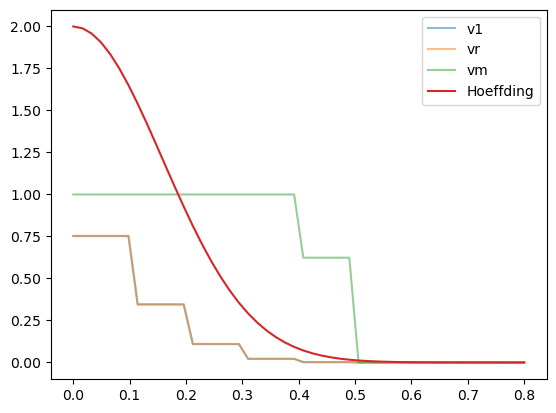

In [8]:
epss = np.linspace(0, 0.8)

for key in v_dict:
    vs = v_dict[key]
    plt.plot(epss, [p(eps, vs, 0.5) for eps in epss], label=key, alpha=0.5)
plt.plot(epss, 2 * np.exp(-2 * (epss ** 2) * 10), label="Hoeffding")
plt.legend()
plt.show()

(8) Welche Münzen gehorchen der Hoeffding-Schranke? Welche nicht? Erläutern Sie, warum welche Münze der Hoeffding-Schranke nicht gehorcht! Wo genau (konzeptionell) verletzt eine Münze die Voraussetzungen der Hoeffding-Ungleichung?

$\nu_1$ und $\nu_r$ gehorchen der Hoeffding-Schranke, $\nu_m$ nicht.

$\nu_m$ wählt nur die Münzen mit den geringsten Anteil an Münzen, die Kopf geworfen wurden. $\nu_m$ verletzt also die gleiche Wahrscheinlichkeit $P$, die für alle Daten gelten muss, indem eine andere Wahrscheinlichkeit "erstellt" wird.

(9) Stellen Sie einen Bezug zum multiplen Urnenproblem aus der Vorlesung her.

Die Wahrscheinlichkeit mit der die Kugeln (1 Münze mit 10 Würfen) aus der Urne (mit 1000 Münzen) gezogen wird, wird in $\nu_m$ so verändert, dass das Trainingsset Münzen, die besonders selten Kopf geworfen haben, bevorzugt.

## 2.2. Perzeptron-Lern-Algorithmus (PLA)

Das Perzeptron haben Sie in der Vorlesung kurz kennengelernt, als wir darüber diskutierten, wie eine Bank entscheiden könnte, ob sie Kunden Kredit gewährt oder nicht. Das Perzeptron lässt sich als ganz einfaches Neuron interpretieren und ist der Ausgangspunkt der Konnektionisten, der Denkschule im Machine Learning, die sich mit neuronalen Netzen beschäftigt. In dieser Übung werden Sie das Perzeptron sowie den Perzeptron-Lern-Algorithmus (PLA) implementieren, mithilfe dessen Hilfe ein Perzeptron auf Daten für Klassifikationsprobleme trainiert werden kann.

PLA lässt sich recht einfach implementieren und erlaubt Ihnen, erste Erfahrungen mit Supervised Machine Learning zu sammeln, ohne dass die Komplexität von Lernalgorithmen in Bibliotheken vor Ihnen versteckt wird.  

* Wenn Sie wünschen, können Sie sich das PDF der Vorlesung in ILIAS herunterladen und noch einmal kurz die Folien nachschlagen, die das Perzeptron behandeln.

Wir gehen in zwei Schritten vor:

1. Wir implementieren das Perzeptron als Funktion.
2. Wir implementieren den Perzeptron-Lern-Algorithmus (PLA).

### 2.2.1 Perzeptron
Sehen Sie sich noch einmal die Folien aus der Vorlesung an. Das Perzeptron $h(\mathbf{x})$ ist definiert wie folgt:

$$h(\mathbf{x}) = \text{sign}(\mathbf{w}^T\mathbf{x})$$

mit Gewichten $w_i$ sowie mit der Vorzeichenfunktion $\text{sign}(s)$, die das Vorzeichen (+1 oder -1) ihres Arguments ausgibt. Wir werden das Perzeptron in zwei Dimensionen ($d=2$) betrachten. Die Vektoren $\mathbf{w}$ und $\mathbf{x}$ habe ich Ihnen für diesen Fall noch einmal notiert:

$$\mathbf{w}\in\{(w_0, w_1, w_2)^T | w_0 \in\mathbb{R}, w_1 \in\mathbb{R}, w_2 \in\mathbb{R} \}$$

und

$$\mathbf{x}\in\{(x_0, x_1, x_2)^T | x_0 = 1, x_1 \in\mathbb{R}, x_2 \in\mathbb{R} \}$$

wobei $w_0$ die Rolle des Schwellwerts $b$ spielt. Wir hatten das Perzeptron im Kontext des Problems der Kreditgewährung kennengelernt, wo $\mathbf{x}$ die Features (Eigenschaften) des Bankkunden sind, $w_i$ die Gewichtung dieser Eigenschaften und $h(\mathbf{x})$ die finale Entscheidung über die Kreditvergabe. Die Aufgabe von PLA wird es sein, die Gewichte $w_i$ und den Schwellwert $b$ so zu verändern (bzw. zu "lernen"), sodass die Entscheidungen ($h(\mathbf{x})$) über den Kredit mit denen übereinstimmen, die die Bankangestellten getroffen haben (um einmal im "Kreditvergabe"-Beispiel zu bleiben). Wir werden natürlich keine Kreditentscheidungen treffen, sondern das Perzeptron auf den Schwertliliendatensatz anwenden, um mithilfe der gemessenen Schwertlilien-Features $\mathbf{x}$ zwischen zwei Schwertlilienarten zu unterscheiden. Dies ist ein Klassifikationsproblem und gehört in den Bereich *Supervised Learning*.

**Ihre Aufgaben:**

(1) Implementieren Sie das Perzeptron als Funktion mit dem Namen `h`, die einen Featurevektor $x$ und einen Gewichtsvektor $w$ entgegennimmt und $h(\mathbf{x})$ zurückgibt. Nutzen Sie die numpy Funktionen `dot` ([Dokumentation](https://docs.scipy.org/doc/numpy/reference/generated/numpy.dot.html)) und `sign` ([Dokumentation](https://docs.scipy.org/doc/numpy/reference/generated/numpy.sign.html)).

In [9]:
def h(x: np.ndarray, w: np.ndarray):
    return np.sign(x.dot(w))

### 2.2.2 PLA Algorithmus

* **Bevor Sie fortfahren,** hier noch ein Hinweis: Sollten Sie einmal aus Versehen eine Endlosschleife bauen und/oder Ihr Algorithmus terminiert nicht, dann wird das Schließen des Browserfensters den Rechenprozess (den Kernel) nicht stoppen. Er wird auf dem Server weiterlaufen. Stattdessen sollten Sie in diesem Fall den Kernel dieses *Jupyter Notebooks* stoppen durch das Menü `Kernel -> Interrupt` oder durch die Tastatur mit: `ESC` (Wechsel in den Command-Mode) und dann zweimal die Taste `i` drücken. Wenn Sie sich für weitere Informationen zu *Jupyter Notebook* interessieren, schauen Sie auch gerne in das Tutorial der Übung 0.4. 
* Vergessen Sie nicht, Ihr *Jupyter Notebook* ab und an zu speichern (mit der Tastenkombination `Strg` + `s`).

Lesen Sie sich zunächst den Algorithmus durch.

#### Der PLA Algorithmus

* **Daten:** $(\mathbf{x_i}, y_i)$ mit $i=1,\ldots,N$. 

Sei $t=0,1,2,\ldots$ der aktuelle Iterationsschritt und sei $\mathbf{w}^{(t)}$ der Vektor $\mathbf{w}$ zum Iterationsschritt $t$. Setze $t=0$ und $\mathbf{w}^{(0)}=\mathbf{0}$.

1. Nutze das Perzeptron mit $\mathbf{w}^{(t)}$ und klassifiziere alle Daten $\mathbf{x_i}, i=1,\ldots,N$. Die durch das Perzeptron vorhergesagten Labels heißen $y_{i,\text{pred}}$.
2. Selektiere irgendein Paar $(\mathbf{x}_j, y_j)$, das falsch klassifiziert wurde (d.h. $y_{j,\text{pred}} \neq y_j$), und nenne es $(\mathbf{x}^{(t)}, y^{(t)})$. Wenn es kein solches Paar gibt, terminiere.
3. Aktualisiere das Gewicht $\mathbf{w}$ mit folgender Regel: $$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)}+y^{(t)}\mathbf{x}^{(t)}$$
4. Erhöhe $t$ um den Wert $1$ und kehre zu Schritt 1 zurück.

**Ihre Aufgaben**

(1) Lesen Sie sich den Algorithmus durch. In welchem Fall terminiert der Algorithmus? *In welchem Fall terminiert der Algorithmus nicht?* Welche Annahme müssen Sie also treffen, damit der Algorithmus terminiert?

* Wenn Sie hier nicht weiterkommen, lesen Sie folgenden Hinweis, den ich Ihnen [ROT13-kodiert](https://rot13.de) hinterlegt habe: Qvr Naanuzr vfg, qnff qvr Qngra yvarne frcnevreone fvaq, q.u. jve xöaara qvr Qngra zvguvysr rvare Trenqra (q=2) bqre Ulcrerorar (q>2) va vuer X_shuffledynffra nhsgrvyra.

Der Algorithmus terminiert nur, wenn die Daten tatsächlich alle von einer Gerade in Dimension 2 oder Hyperebene in höheren Dimensionen getrennt werden können. Es muss also vorausgesetzt werden, dass die Daten keine Streuung haben.

(2) In der folgenden Code-Zelle finden Sie einen synthetischen Datensatz, an den wir ein Perzeptron mithilfe von PLA trainieren wollen. Führen Sie den unten stehenden Code aus und betrachten Sie die dadurch entstehende Abbildung. Die Funktionen im Bereich "Helper Functions" sind für Sie nicht weiter relevant. Sie dienen nur der Erzeugung des Datensatzes.

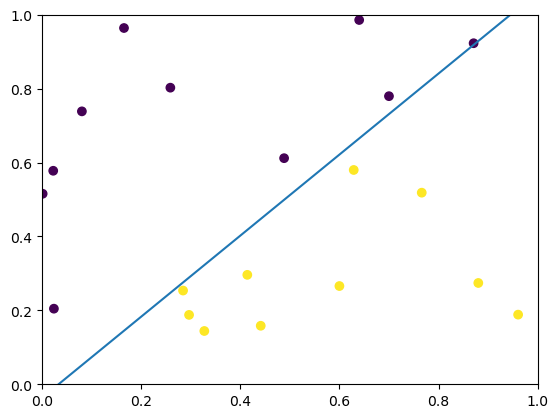

In [10]:
import numpy as np
from matplotlib import pyplot as plt
# For an explanation of the next line, 
# see https://jakevdp.github.io/PythonDataScienceHandbook/04.00-introduction-to-matplotlib.html
%matplotlib inline 

# --------- START - Helper functions that you don't need to care about ---------

def generate_points(N):
    return np.random.rand(N, 2)


def generate_decision_line():
    g = generate_points(2)
    m = (g[1, 1] - g[1, 0]) / (g[0, 1] - g[0, 0])
    b = g[1, 0] - m * g[0, 0]

    def getY(x):
        return m * x + b

    func = getY
    return func


# This function creates an "unknown" target function f.
# f is then used to create labels y for points X.
# X is a matrix containing N rows (the data points) of
# with 2 dimensions (columns) each.
def getClassedPoints(N):
    np.random.seed(5)
    f = generate_decision_line()  # target function
    X = generate_points(N)  # data set
    y = np.array([1 if f(X[i, 0]) > X[i, 1] else -1
                  for i in range(X.shape[0])])  # labels
    return X, y, f


# --------- END -  Helper functions that you don't need to care about  ---------

# Obtain points X, labels y, and target function f.
# Note that in real world problems, we do not know f.
X, y, f = getClassedPoints(20)

# Visualize data
plt.scatter(X[:, 0], X[:, 1], c=y)  # plots the data points
plt.plot(np.array([0, 1]), f(np.array([0, 1])))  # plots the target function
plt.axis((0, 1, 0, 1))  # ensures that we see the relevant part of the feature space
plt.show()

(3) Untersuchen Sie die Daten und beantworten Sie folgende Fragen: Wieviele Datenpunkte enthält der Datensatz? Wieviele Features besitzt jeder Datenpunkt?

In [ ]:
print(f"Der Datensatz enthält {X_shuffled_shuffled.shape[0]} Datenpunkte mit jeweils {X.shape[1]} Features.")

Der Datensatz enthält 20 Datenpunkte mit jeweils 2 Features.


(4) Nehmen Sie sich die Folien der Vorlesung zur Hand. Klären Sie für sich die Frage: Wieviele Einträge besitzt der Gewichtsvektor?

Immer ein Eintrag mehr, als es Features gibt, da der Bias noch dazu gezählt wird.

(5) Implementieren Sie nun den Perzeptron-Lernalgorithmus (PLA) als Funktion mit dem Namen `pla`, die die Feature-Datenmatrix X (Nx2 Matrix), den Labelvektor $\mathbf{y}$ sowie Gewichte $\mathbf{w}^{(t)}$ entgegennimmt und die finalen Gewichte $\mathbf{w}_\text{final}$ zurückgibt.

*Hinweise:*
* Die Funktion `pla` sollte sich selber rekursiv aufrufen, sofern ein Datenpunkt gefunden wurde, der durch das Perzeptron mit den aktuellen Gewichten $\mathbf{w}^{(t)}$ nicht korrekt klassifiziert wird.
* Der Schwellwert ist im Gewichtsvektor $\mathbf{w}$ als 0-te Komponente enthalten ($w_0$). Der korrespondierende Datenwert $x_0$ ist aber in den Featurevektoren noch nicht enthalten. Schreiben Sie Ihre Funktion `pla` so, dass sie dort jeden untersuchten Featurevektor um die 0-te Komponente erweitern, bevor Sie ihn Ihrer Funktion "h" übergeben. Sie können [np.hstack](https://docs.scipy.org/doc/numpy/reference/generated/numpy.hstack.html) dafür verwenden.

In [12]:
def pla(X, y, w, verbose=False):
    X_stacked = np.hstack((np.ones(((X.shape[0], 1))), X))
    w_trace = []
    w_final = _pla_help(X_stacked, y, w, w_trace)
    if verbose:
        return w_final, w_trace
    return w_final

def _pla_help(X_stacked, y, w, w_trace):
    y_pred = h(X_stacked, w)
    bools = y_pred == y
    if np.all(bools):
        return w
    idx = np.argmin(bools)
    x_t = X_stacked[idx]
    y_t = y[idx]
    w_next = w + y_t * x_t
    w_trace.append(w_next)
    return _pla_help(X_stacked, y, w_next, w_trace)

(6) Implementieren Sie eine Funktion `g`, die Ihnen die Entscheidungsgerade berechnet, die durch die von Ihrem Perzeptron gelernten Gewichte definiert wird. Die Funktion `g` nimmt einen Wert $x_1$ sowie den finalen Gewichtsvektor $\mathbf{w}_\text{final}$ entgegen und gibt den Funktionswert $x_2$ der Entscheidungsgeraden $x_2 = g(x_1)$ zurück. Um `g` implementieren zu können, überlegen Sie sich, wie Sie aus den Gewichten des Perzeptrons eine Gleichung für eine Gerade bestimmen können, die die beiden Klassen voneinander trennt.

* Wenn Sie hier partout nicht weiterkommen, lesen Sie diesen Hinweis für die Herleitung der Gleichung ([ROT-13 kodiert; aktivieren Sie zusätzlich ROT-5](https://rot13.de)): Orgenpugra Fvr qnf Cremrcgeba, haq uvre vaforfbaqrer qnf Nethzrag qre Fvtahzfshaxgvba, hz qvr Trenqratyrvpuhat uremhyrvgra: Fvr züffra $znguos{j}^grkg{G} znguos{k} = 5$ frgmra, jrvy fvpu tranh na Fgryyr ragfpurvqrg, bo rva Srngherirxgbe qre rvara Xynffr (>5) bqre qre naqrera Xynffr (<5) mhtrbeqarg jveq. Jraa Fvr $znguos{j}^grkg{G} znguos{k} = 5$ trfrgmg unora, yöfra Fvr qvrfr anpu  $k_7$ nhs. Qnzvg reunygra Fvr rvar Tyrvpuhat qre Sbez $k_7 = z k_6 + p$ zvg Trenqrafgrvthat $z$ haq $k_7$-Npufraqheputnat $p$. Qvrfr Trenqr ragfcevpug qre Shaxgvba `t`. 

$$\left\langle \begin{pmatrix} 1 \\ x_1 \\ x_2 \end{pmatrix},\begin{pmatrix} b \\ w_1 \\ w_2 \end{pmatrix} \right\rangle = b + w_1 \cdot x_1 + w_2 \cdot x_2$$
$$\Rightarrow x_2=\frac{b + w_1 \cdot x_1}{-w_2}$$

In [13]:
def g(x_1, w):
    return (w[0] + w[1] * x_1) / (-w[2])

(7) Visualisieren Sie die Daten $X$ sowie die Target Function $f$ und die vom Perzeptron (Funktion `pla`) gefundene Entscheidungsgerade $g$ in einem [Scatterplot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html).

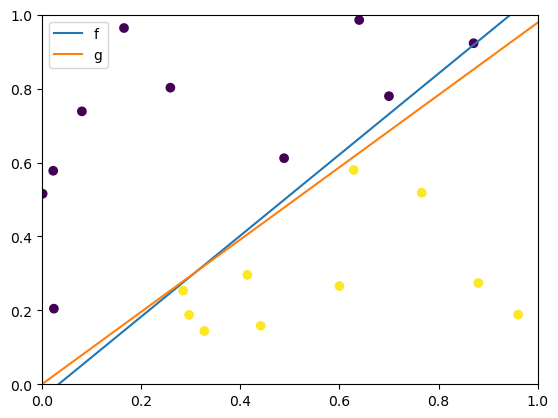

In [14]:
w_final = pla(X, y, np.zeros(X.shape[1] + 1))

plt.scatter(X[:, 0], X[:, 1], c=y)  # plots the data points
plt.plot(np.array([0, 1]), f(np.array([0, 1])), label="f")  # plots the target function
plt.plot(np.array([0, 1]), g(np.array([0, 1]), w_final), label="g") # plots the learned function g
plt.axis((0, 1, 0, 1))  # ensures that we see the relevant part of the feature space
plt.legend()
plt.show()

## 2.3 Klassifikation der Schwertliliendaten

* **Bevor Sie fortfahren,** hier noch ein Hinweis: Sollten Sie einmal aus Versehen eine Endlosschleife bauen und/oder Ihr Algorithmus terminiert nicht, dann wird das Schließen des Browserfensters den Rechenprozess (den Kernel) nicht stoppen. Er wird auf dem Server weiterlaufen. Stattdessen sollten Sie in diesem Fall den Kernel dieses *Jupyter Notebooks* stoppen durch das Menü `Kernel -> Interrupt` oder durch die Tastatur mit: `ESC` (Wechsel in den Command-Mode) und dann zweimal die Taste `i` drücken. Wenn Sie sich für weitere Informationen zu *Jupyter Notebook* interessieren, schauen Sie auch gerne in das Tutorial in den ersten Aufgaben dieses Kurses. 
* Vergessen Sie nicht, Ihr *Jupyter Notebook* ab und an zu speichern (mit der Tastenkombination `Strg` + `s`).

Sie haben in der vorherigen Übung 1.2 den Schwertliliendatensatz bereits einmal kennengelernt und erste Einsichten gewonnen. Als kurze Erinnerung habe ich Ihnen unten Feature-Paare geplottet. Daneben finden Sie in dem nachfolgenden Foto Beispiele der drei Schwertlilienarten, die Sie untersuchen:

![Schwertlilien](https://data.bialonski.de/ml/schwertlilien.png)

* Führen Sie einfach die folgende Code-Zelle aus.

Anzahl unterschiedlicher Featurepaare: 6.0


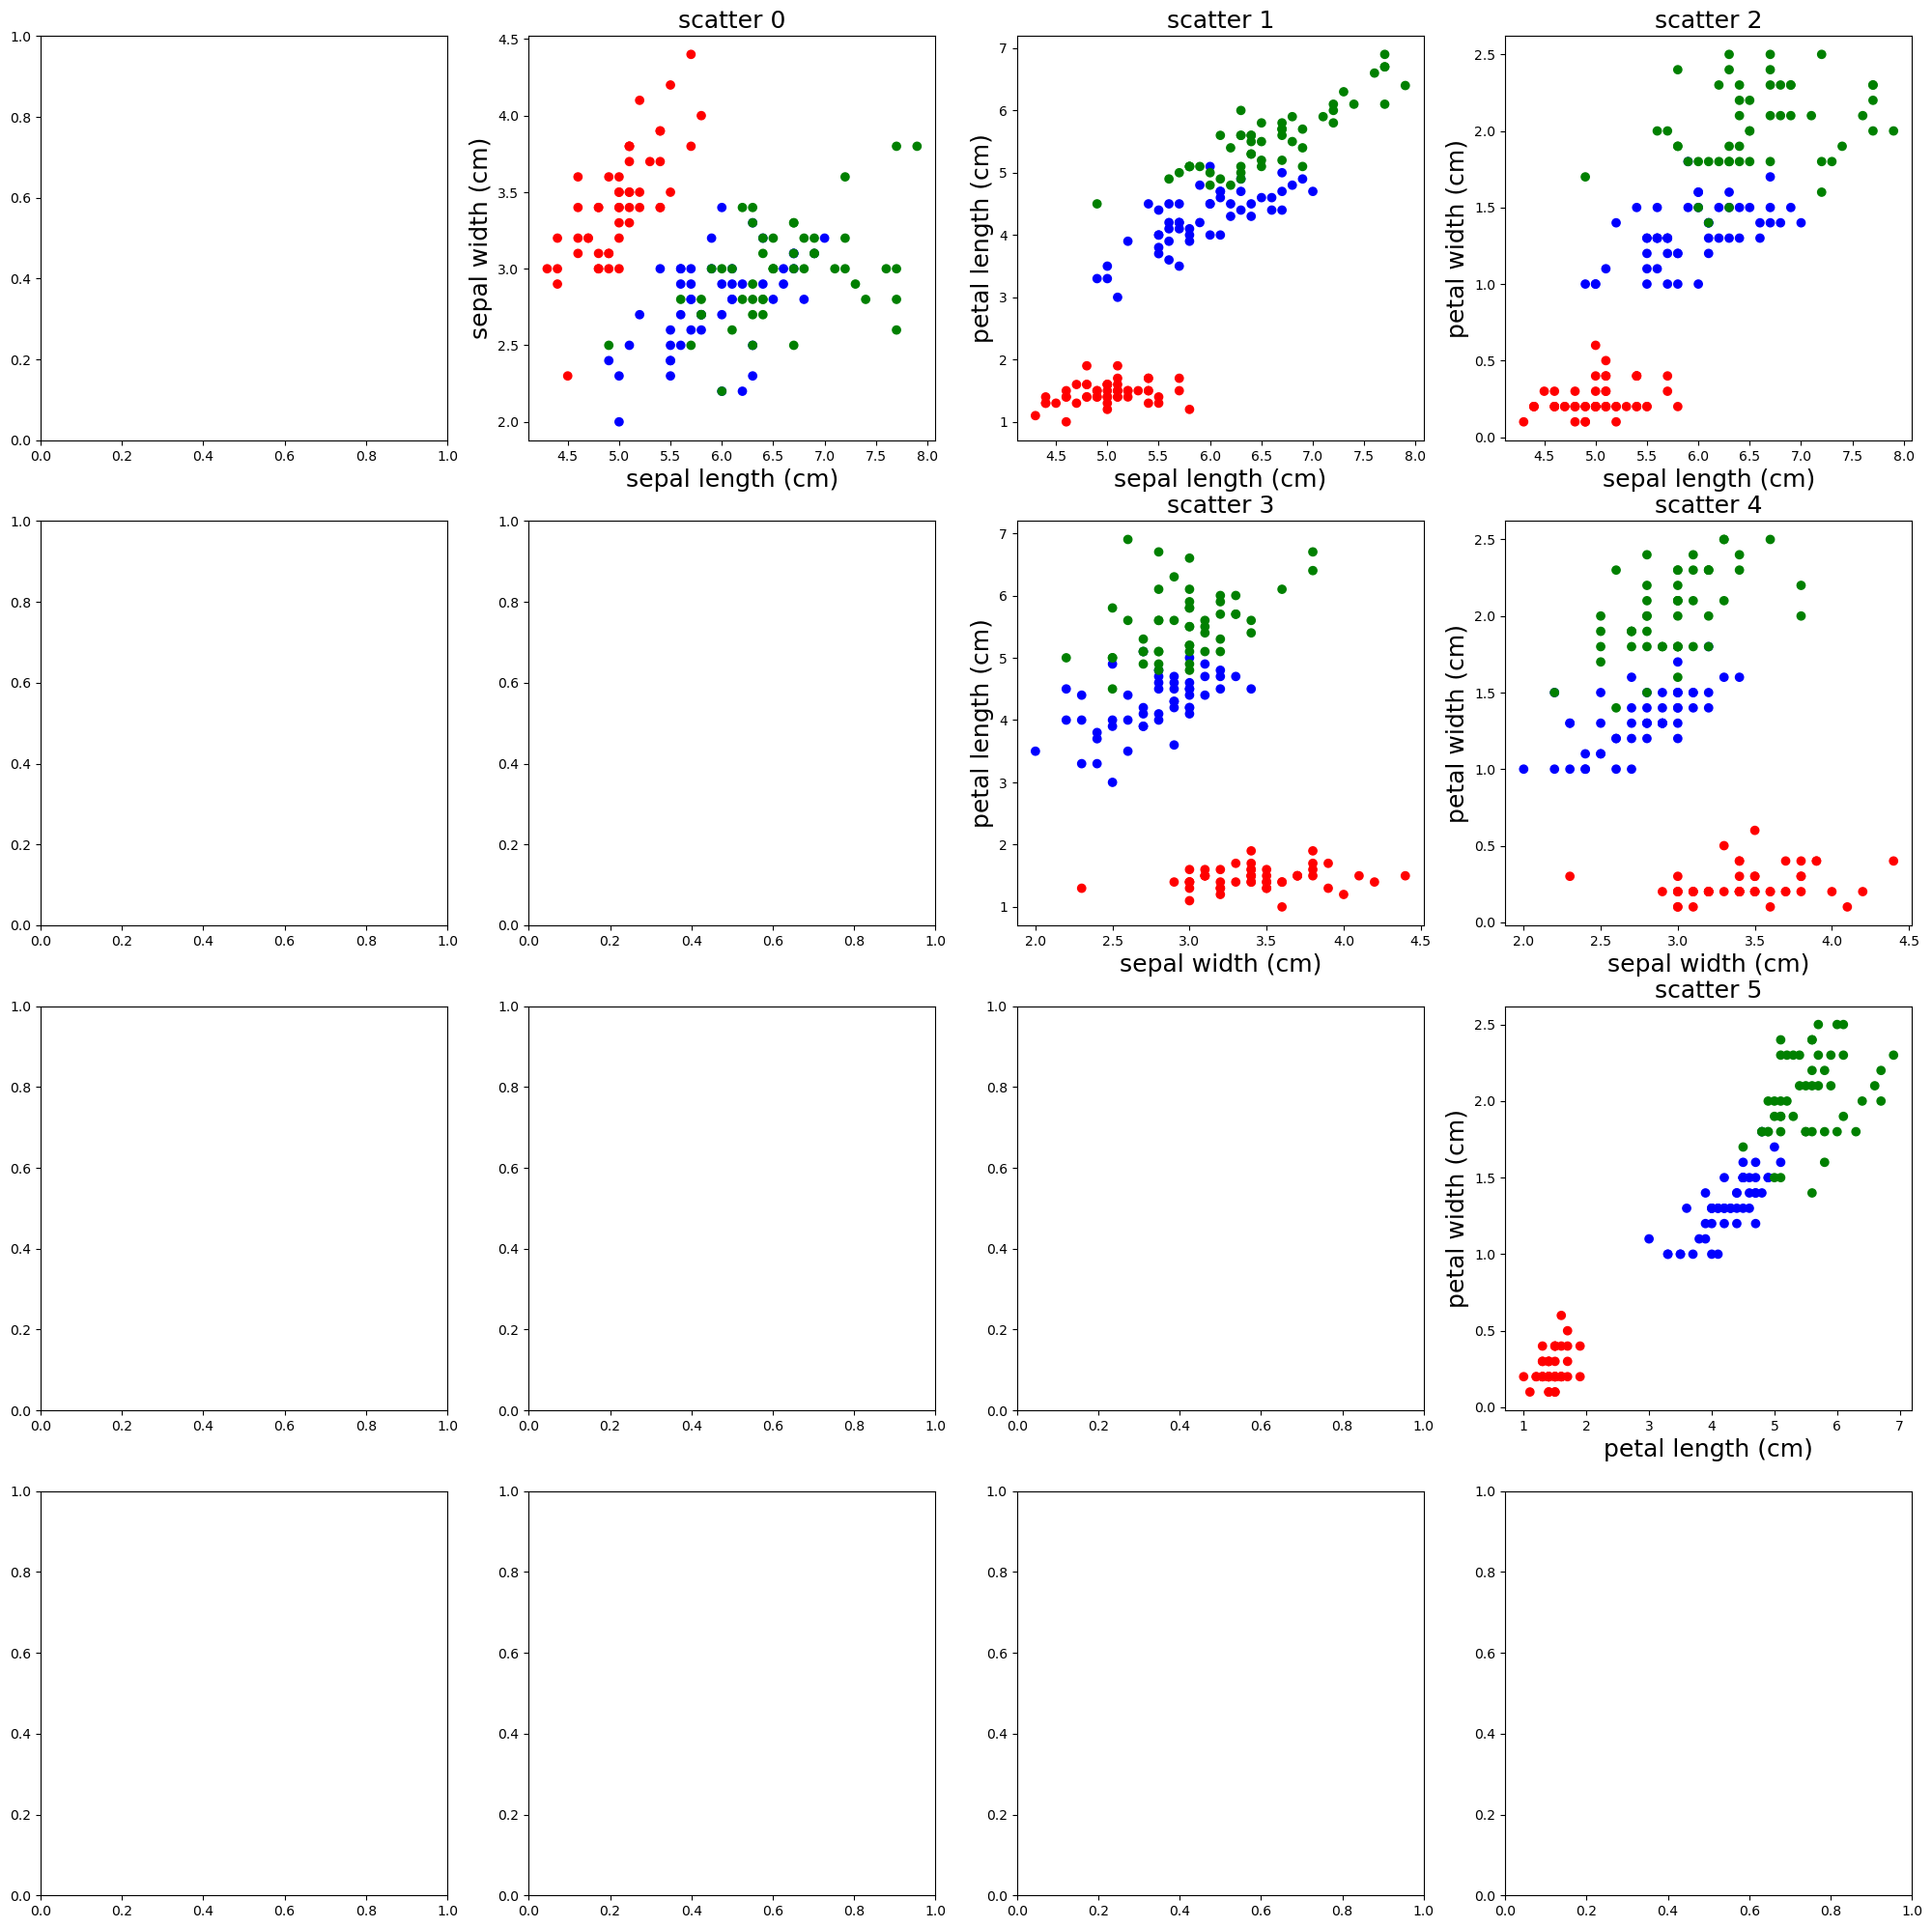

['red: setosa', 'blue: versicolor', 'green: virginica']


In [15]:
import numpy as np 
from matplotlib import pyplot as plt
%matplotlib inline

# import IRIS dataset
from sklearn.datasets import load_iris
data = load_iris()

feature_count = len(data['feature_names'])
print('Anzahl unterschiedlicher Featurepaare:', (feature_count**2 - feature_count)/2 )

# scatter plot for feature pairs
feature_pairs = [(x,y) for x in range(feature_count) for y in range(x+1,feature_count)]
_, plots = plt.subplots(nrows = 4, ncols = 4, figsize=(25,25))

# color coding for each feature
colors = ['red', 'blue', 'green']
color_code = []
for idx, target in enumerate(data['target']):
    if target == 0:
        color_code.append('red')
    elif target == 1:
        color_code.append('blue')
    elif target == 2:
        color_code.append('green')

# print scatter in grid
for idx, pair in enumerate(feature_pairs):
    x_i = pair[0]
    y_i = pair[1]
    plots[x_i][y_i].scatter(data['data'][:, x_i], data['data'][:, y_i], c=color_code)
    plots[x_i][y_i].set_xlabel(data['feature_names'][x_i], fontsize=18)
    plots[x_i][y_i].set_ylabel(data['feature_names'][y_i], fontsize=18)
    plots[x_i][y_i].set_title('scatter ' + str(idx), fontsize=18)

plt.show()

# print legend
legend = [ color_name + ': ' + data['target_names'][idx] for idx, color_name in enumerate(colors) ]
print(legend)

**Ihre Aufgaben:**

(1) Entscheiden Sie sich für ein Feature-Paar, von dem Sie der Überzeugung sind, dass sich **eine** Schwertlilienart linear von den anderen beiden Schwertlilienpaaren separieren lässt. Nennen Sie kurz das Paar, für das Sie sich entschieden haben.

Petal Length und Petal width können verwendet werde, um setosa von versicolor und virginica abzutrennen

(2) Wenden Sie den PLA auf dieses Feature-Paar an und visualisieren Sie das Ergebnis (d.h. die Vorhersagen des durch PLA fertig trainierten Perzeptrons) in einem Scatter-Plot.
   * Damit Sie PLA anwenden können, werden Sie die Labels der beiden Schwertlilienarten, die Sie nicht linear separieren können, in eine Klasse zusammenfassen, sodass Sie es mit einem binären Klassifikationsproblem zu tun haben, also einem Problem, bei dem Sie nur noch zwischen zwei Klassen unterscheiden wollen. Transformieren Sie also die Labels des obigen Datensatzes so, dass Sie es am Ende mit "+1" und "-1" zu tun haben.
   * In Ihrem Scatter-Plot können Sie die "wahren" Labels bzw. Klassenzugehörigkeiten beispielsweise farbkodieren ([Parameter *c*](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html)) und zusätzlich die vorhergesagten Labels des Perzeptrons mit unterschiedlichen [Marker-Symbolen](https://matplotlib.org/stable/api/markers_api.html) kodieren (hier werden Sie voraussichtlich `scatter` mehrfach aufrufen müssen, nämlich einmal pro Marker-Symbol).

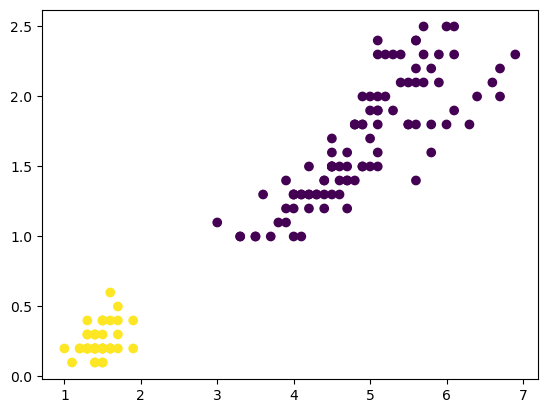

In [16]:
X_selected = np.array([data.data[:, -2], data.data[:, -1]]).T
targets_binary = np.copy(data.target)
targets_binary[targets_binary > 0] = -1
targets_binary[targets_binary == 0] = 1
plt.scatter(X_selected[:, 0], X_selected[:, 1], c=targets_binary)
plt.show()

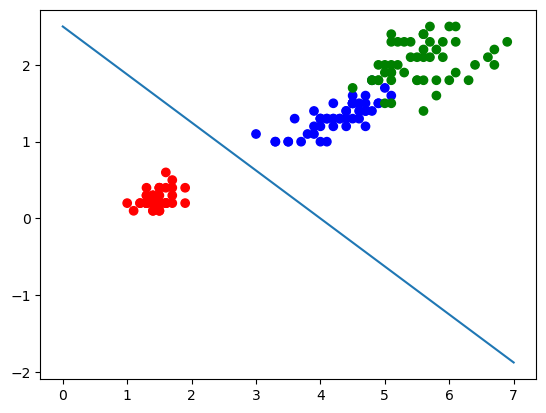

In [17]:
w_final_2 = pla(X_selected, targets_binary, np.zeros(X_selected.shape[1] + 1))

plt.scatter(X_selected[:, 0], X_selected[:, 1], c=color_code)
plt.plot(np.array([0, 7]), g(np.array([0, 7]), w_final_2), label="g") # plots the learned function g
plt.show()

(3) Fügen Sie Ihrer Visualisierung die Entscheidungsgerade hinzu, die durch das Perzeptron (bzw. dessen Gewichtsvektor $\mathbf{w}$) definiert wird. Diese Gerade ist die "finale Hypothese" *g*, die Ihnen von PLA mitgeteilt wurde.
   * Wenn Sie einen Hinweis brauchen, wie Sie die finale Hypothese als Gerade formulieren können, schlagen Sie den Hinweis in Aufgabe 2.2.2 Schritt (6) nach.

(4) Erzeugen Sie einen weiteren Scatter-Plot, der neben den Feature-Paaren die Entscheidungsgeraden anzeigt, die zu jedem Schritt des Perzeptron-Lern-Algorithmus ausgegeben werden. Sie können dadurch beobachten, wie Ihr Algorithmus langsam zu einem Ergebnis konvergiert. Wenn Ihnen die Darstellung zu unübersichtlich wird, schränken Sie die Anzahl der Entscheidungsgeraden für wenige, aufeinanderfolgende Iterationsschritte ein.
   * Für die Python-Professionals unter Ihnen: Sie können gerne die Entscheidungsgeraden so farbkodieren, sodass die Farbe kräftiger wird mit steigenden Iterationsschritten.

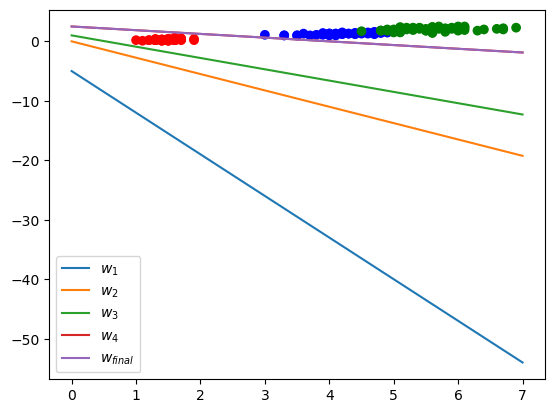

In [18]:
w_final_2, w_trace = pla(X_selected, targets_binary, np.zeros(X_selected.shape[1] + 1), verbose=True)

plt.scatter(X_selected[:, 0], X_selected[:, 1], c=color_code)
for i, w_t in enumerate(w_trace):
    plt.plot(np.array([0, 7]), g(np.array([0, 7]), w_t), label=f"$w_{i+1}$") # plots the learned function g

plt.plot(np.array([0, 7]), g(np.array([0, 7]), w_final_2), label="$w_{final}$") # plots the learned function g
plt.legend()
plt.show()

(5) Können Sie beantworten, ob ihr Modell gute Klassifikationen geben wird für Schwertlilienarten, die ich Ihnen nicht zum Training Ihres Perzeptrons zur Verfügung gestellt habe?
   * Falls ja, begründen Sie dies in wenigen Sätzen.
   * Falls nein, begründen Sie dies in wenigen Sätzen.

In [19]:
print(data.data.shape)

(150, 4)


Da in diesem Fall nur eine Hypothese der linearen Separierbarkeit verwendet wurde, trifft die Hoeffding-Ungleichung mit $2\cdot\exp^{-2\epsilon^2N}$ ein. N ist dabei 150

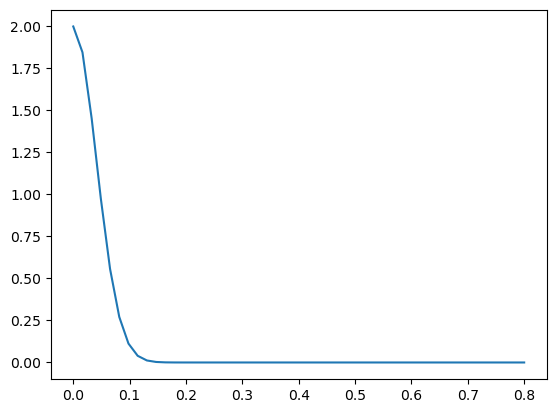

In [20]:
plt.plot(epss, 2 * np.exp(-2 * (epss ** 2) * 150))
plt.show()

Aus dem Plot kann man erkennen, dass die Wahrscheinlichkeit, dass die Hypothese von der tatsächlichen Funktion um mehr als epsilon abweicht, schon bei einem Epsilon von nur c.a. 0.15 beinahe 0 beträgt, die Funktion also wahrscheinlich gut generalisiert.

Sie sind fertig mit dieser Teilaufgabe? Dann darf ich Ihnen gratulieren: Sie haben - in ganz einfacher Weise - wichtige Schritte in einem Machine Learning Projekt nachvollzogen:

1. Sie haben sich Daten in der letzten Übung angesehen.
2. Sie haben Features identifiziert und eine Intuition darin gewonnen, wie sich anhand von Daten eine Schwertlilienart von anderen Arten unterscheiden lässt. Dieser Schritt ist eine ganz einfache Version dessen, was man "**Feature Engineering**" nennt, also das Finden von Features, mithilfe derer sich Modelle erfolgreich trainieren lassen. 
3. Sie haben ein einfaches Modell eines Neurons (das Perzeptron) trainiert, mit dem Sie eine Schwertlilienart von den anderen unterscheiden können.

Wenn Sie im Bereich *angewandtes Machine Learning* in einem Unternehmen einmal arbeiten werden, dann ist es recht wahrscheinlich, dass rund 80% Ihrer Arbeitszeit in den Schritt 1 und vor allem Schritt 2 fließt, während Sie sich mit Schritt 3 die restlichen 20% beschäftigen. Wenn Sie forschend oder forschungsnah im Bereich *Machine Learning* tätig werden sollten, so dreht sich dieses Verhältnis um: Sie werden sich etwa 80% Ihrer Zeit mit Schritt 3 und dem Weiter- oder Neuentwickeln von Lernmodellen beschäftigen.

## 2.4 \[Optional\] PLA und synthetische Daten
In der Übung letzter Woche haben einige von Ihnen bereits eine Funktion implementiert, die einen synthetischen Datensatz generiert, der linear separierbar ist. Wir werden diese Funktion nutzen, um PLA zu untersuchen. Wenn Sie Ihre eigene Funktion nutzen möchten (sofern Sie sie geschrieben haben), kopieren Sie sie gerne in dieses Notebook. Wenn nicht, dann nutzen Sie die unten stehende Lösung.

* Die Ihnen hier zur Verfügung gestellte Lösung zur Generierung eines synthetischen Datensatzes ist recht allgemein: Sie würfelt zwei Zufallspunkte in der Ebene und legt durch diese zwei Punkte eine [Gerade](https://de.wikipedia.org/wiki/Geradengleichung#Haupt-_oder_Normalform). Die resultierenden Werte für die Geradensteigung $m$ und den Achsenabschnitt $b$ werden dann berechnet.

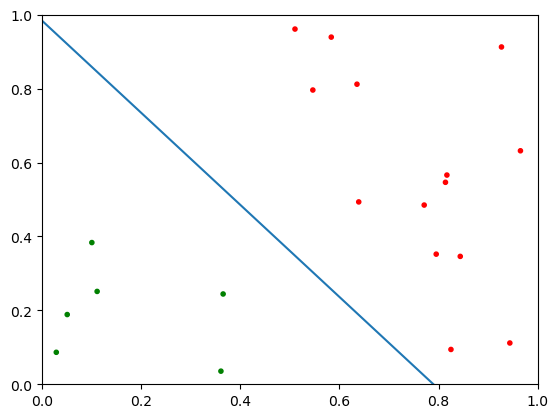

In [21]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

def generate_points(N):
    return np.random.rand(N, 2)
    
def generate_decision_line():
    g = generate_points(2)
    m = (g[1, 1]-g[1, 0])/(g[0, 1]-g[0, 0])
    b = g[1, 0]-m*g[0, 0]
    def getY(x):
        return m*x+b
    func = getY
    return func


def getClassedPoints(N):
    f = generate_decision_line()  # target function
    X = generate_points(N)  # data set
    y = np.array([1 if f(X[i, 0]) > X[i, 1] else -1
                  for i in range(X.shape[0])])  # labels
    return X, y, f


# Obtain points X, labels y, and target function "target_function".
# Note that in real world problems, we do not know the target function.
X, y, target_function = getClassedPoints(20)

# create color labels according to target values
lookup = np.array(["r", "g"])
c = lookup[(y+1)//2]

# plot points
plt.axis((0, 1, 0, 1))
plt.scatter(X[:,0], X[:,1], c=c, marker='.')

# plot decision line
l = np.linspace(0, 1, 2)
plt.plot(l, target_function(l))
plt.show()

**Ihre Aufgaben:**

Wir wollen das Verhalten von PLA untersuchen, insbesondere, wie die Iterationsanzahl von der Anzahl der Datenpunkte abhängt.

(1) Erzeugen Sie einen synthetischen Datensatz mit 20 Punkten und wenden Sie PLA darauf an. Erfassen Sie dabei die Anzahl der Iterationen, die PLA benötigt hat. Visualisieren Sie den Datensatz und die finale Hypothese (Gerade), die durch PLA generiert, sowie die tatsächliche Linie, über die die Daten generiert wurden. Kommentieren Sie die Ähnlichkeit oder Unähnlichkeit beider Geraden.

Die PLA benötigte 6 Iterationen


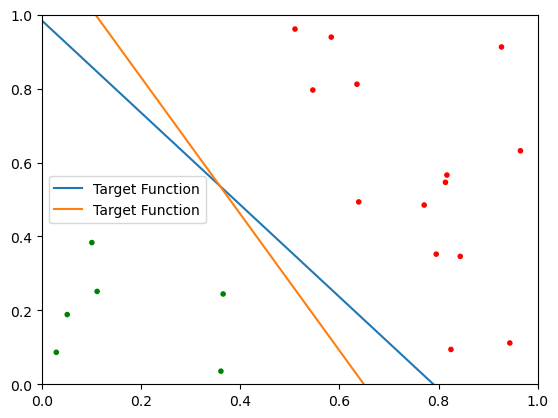

In [37]:
w_final_3, w_trace = pla(X, y, np.zeros(3), verbose=True)
print(f"Die PLA benötigte {len(w_trace) + 1} Iterationen")
plt.axis((0, 1, 0, 1))
plt.scatter(X[:,0], X[:,1], c=c, marker='.')

# plot decision line
l = np.linspace(0, 1, 2)
plt.plot(l, target_function(l), label="Target Function")
plt.plot(l, g(l, w_final_3), label="Target Function")
plt.legend()
plt.show()

Die beiden Geraden sind, obwohl sie die Punkte beide richtig klassifizieren, einigermaßen unähnlich. 

(2) Wiederholen Sie Punkt (1) mit einem neuen synthetischen Datensatz derselben Größe (also 20 Punkte). Wie viele Iterationen braucht PLA nun?

(3) Wiederholen Sie Punkt (2) mit demselben synthetischen Datensatz, doch permutieren Sie die Reihenfolge, in der die Datenpunkte des Datensatzes im Array stehen, zufällig. Wie viele Iterationen benötigt PLA nun?

In [26]:
def unison_shuffled_copies(a, b, c):
    assert len(a) == len(b) == len(c)
    p = np.random.permutation(len(a))
    return a[p], b[p], c[p]

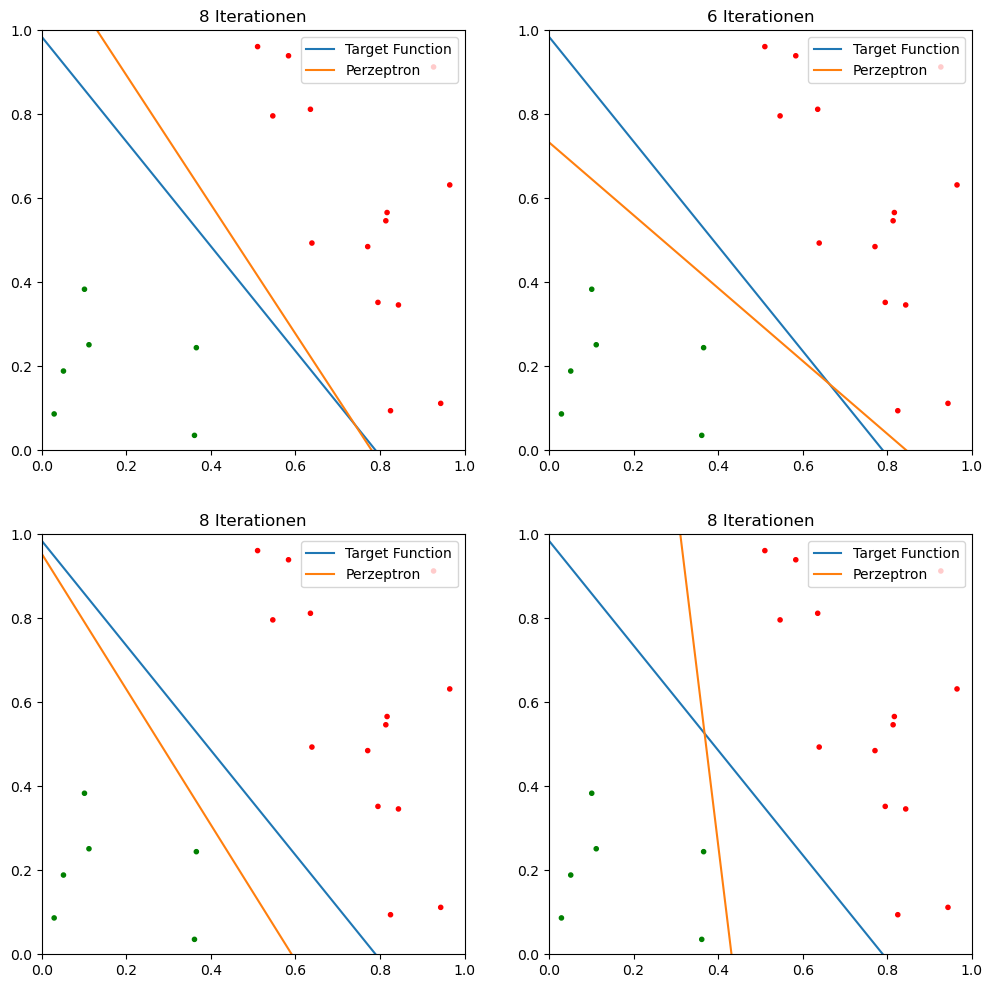

In [54]:
_, ax = plt.subplots(2, 2, figsize=(12, 12))
ax = ax.flatten()

for i in range(4):
    X_shuffled, y_shuffled, c_shuffled = unison_shuffled_copies(X, y, c)
    w_final_3, w_trace = pla(X_shuffled, y_shuffled, np.zeros(3), verbose=True)
    ax[i].axis((0, 1, 0, 1))
    ax[i].scatter(X_shuffled[:,0], X_shuffled[:,1], c=c_shuffled, marker='.')

    # plot decision line
    l = np.linspace(0, 1, 2)
    ax[i].plot(l, target_function(l), label="Target Function")
    ax[i].plot(l, g(l, w_final_3), label="Perzeptron")
    ax[i].legend()
    ax[i].set_title(f"{len(w_trace) + 1} Iterationen")
plt.show()

Die Anzahl der Iterationen variiert sehr stark, ist aber in den Angegebenen Beispielen größer, als bei den nicht geshuffelten Daten. Die Unähnlichkeit der Geraden variiert ebenfalls stark. In einigen Iterationen, wie oben Rechts, sind die Geraden sehr ähnlich, in anderen, wie unten Rechts sehr unähnlich.

(4) Erzeugen Sie 100 synthetische Datensätze der Größe 20 und ermitteln Sie für jeden Datensatz die Iterationsanzahl von PLA. Erzeugen Sie ein Histogramm, das die Häufigkeit der auftretenden Iterationsanzahl darstellt. 
   * Wie interpretieren Sie dieses Histogramm?

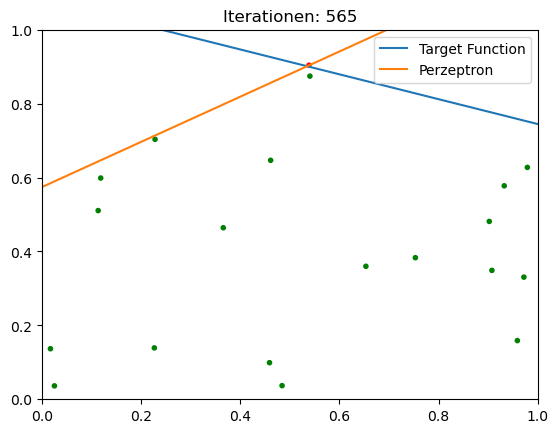

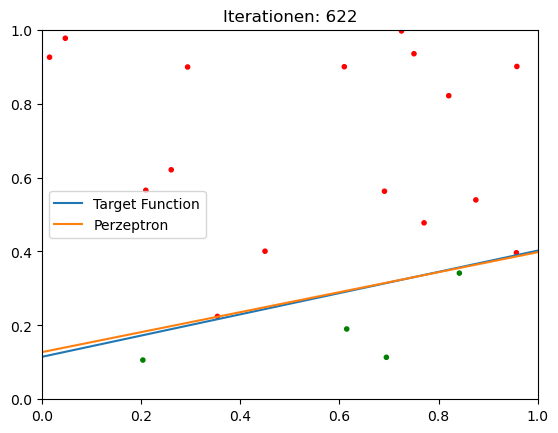

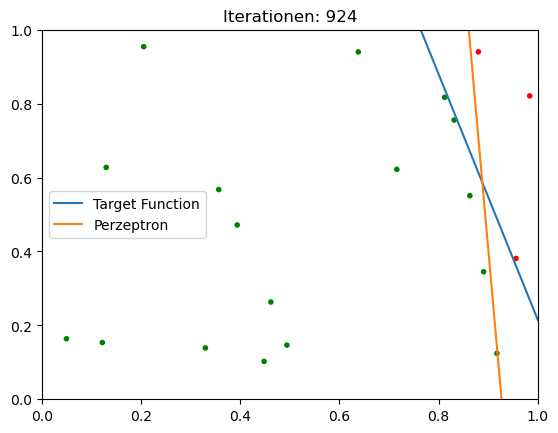

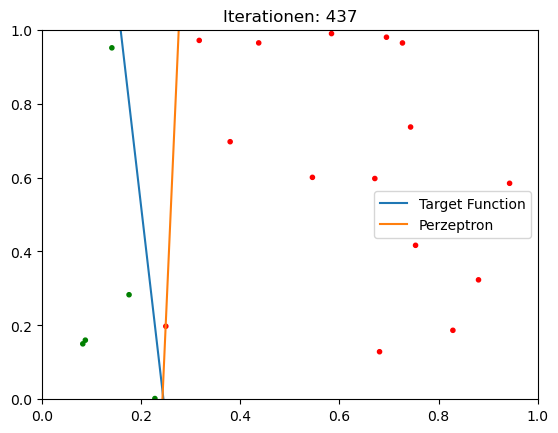

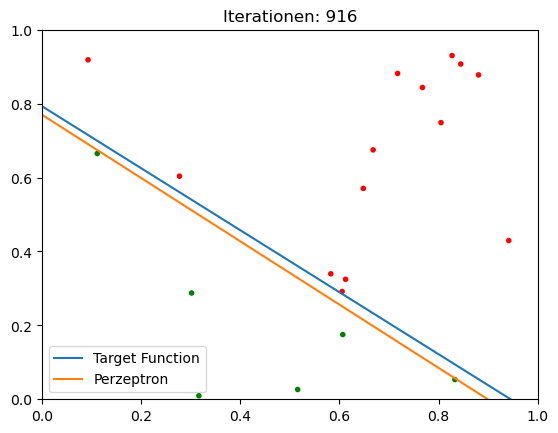

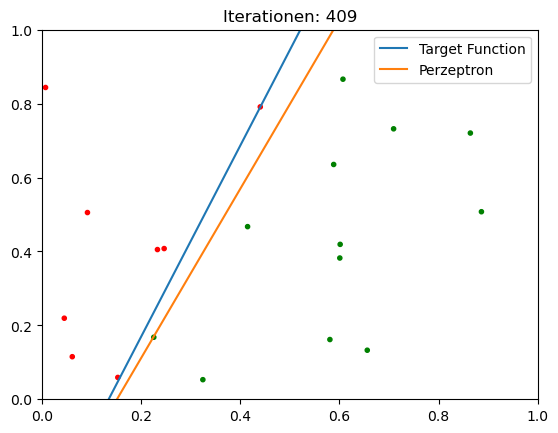

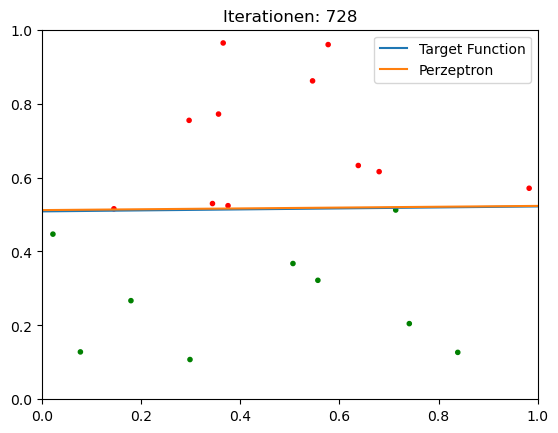

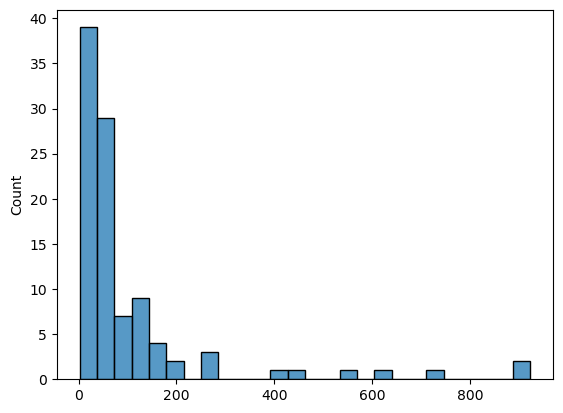

In [61]:
iterationen = []
for i in range(100):
    X_i, y_i, target_i = getClassedPoints(20)
    w_i, w_trace_i = pla(X_i, y_i, np.zeros(3), verbose=True)
    iterationen.append(len(w_trace_i) + 1)
    if len(w_trace_i) + 1 > 300:
        # create color labels according to target values
        lookup = np.array(["r", "g"])
        c_i = lookup[(y_i+1)//2]

        # plot points
        plt.axis((0, 1, 0, 1))
        plt.scatter(X_i[:,0], X_i[:,1], c=c_i, marker='.')

        # plot decision line
        l = np.linspace(0, 1, 2)
        plt.plot(l, target_i(l), label="Target Function")
        plt.plot(l, g(l, w_i), label="Perzeptron")
        plt.legend()
        plt.title(f"Iterationen: {len(w_trace_i) + 1}")
        plt.show()

sns.histplot(iterationen)
plt.show()

(5) Fassen Sie Ihre Beobachtungen kurz in wenigen Sätzen zusammen.

Die meisten Iterationszahlen halten sich im 10-20 Itertionsbereich. Es gibt allerdings Ausreißer, die sehr viele Iterationen benötigen. Das kommt davon, wenn Punkte sehr nahe an der Target function liegen. In solchen Fällen muss w präziser und ähnlich zu der Target Function sein.

(6) Diejenigen unter Ihnen, die durch diese Übung "gerauscht" sind und noch Zeit und Energie verspüren, können sich gerne folgender Frage widmen:

* Wie verhält sich die Iterationsanzahl von PLA in Abhängigkeit der Punktanzahl $N$ und der Raumdimension $d$, in der die Punkte leben?

Passen Sie dazu die Funktion an, die den synthetischen Datensatz generiert, um Räume mit $d>2$ zuzulassen, und scannen Sie den Parameterraum für $N$ und $d$ (wählen Sie den Parameterraum nicht zu groß - etwa 3 Werte für $N$ und 3 Werte für $d$ sollten genügen). Führen Sie für jedes $(N, d)$ Paar ein Training durch und zeichnen die Iterationsanzahl auf. Wiederholen Sie den Vorgang und erzeugen damit ein kleines Ensemble (etwa 10-20 Ensemblemitglieder) für jedes $(N, d)$ Paar. Die entstehenden Histogramme eines $(N, d)$ Paares können Sie über Kenngrößen charakterisieren, beispielsweise über Mittelwerte oder Mediane. Visualisieren Sie Ihre gewählte Kenngröße in Abhängigkeit von $N$ und $d$. Wie interpretieren Sie Ihre Beobachtungen?